# Model Training and Tuning

## In this, We will train both models properly, tune them, and make sure you hit the targated RMSE.

In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

In [3]:
#random forest model
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,12
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [4]:
rf_pred = rf.predict(X_test)

rmse_rf = mean_squared_error(y_test, rf_pred)
print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 11.57468535691722


In [5]:
# XGBoost Model
xgb = XGBRegressor(
    n_estimators=700,
    learning_rate=0.02,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [6]:
xgb_pred = xgb.predict(X_test)

rmse_xgb = mean_squared_error(y_test, xgb_pred)
print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 6.001760959625244


In [7]:
print("Model Comparison:")
print("------------------")
print(f"Random Forest RMSE: {rmse_rf:.2f}")
print(f"XGBoost RMSE: {rmse_xgb:.2f}")

Model Comparison:
------------------
Random Forest RMSE: 11.57
XGBoost RMSE: 6.00


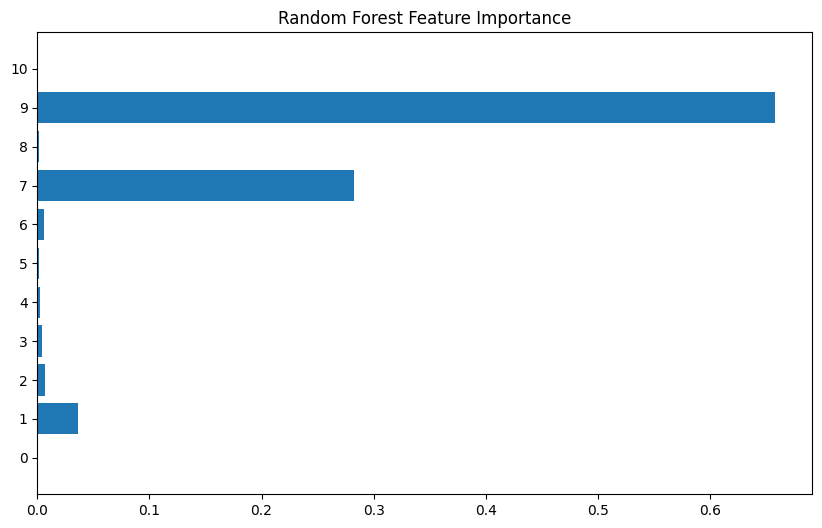

In [8]:
# RF feature importance
import matplotlib.pyplot as plt

importance_rf = rf.feature_importances_
features = X_train.columns

plt.figure(figsize=(10,6))
plt.barh(features, importance_rf)
plt.title("Random Forest Feature Importance")
plt.show()

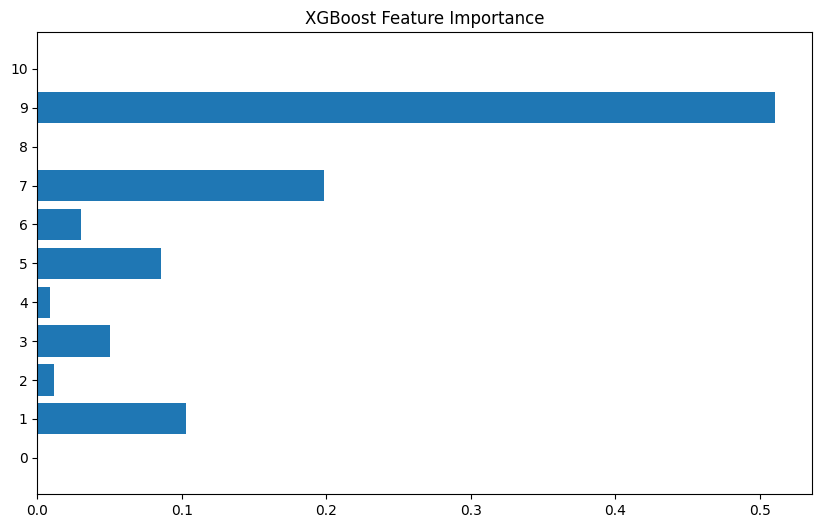

In [9]:
# XGB feature importance
importance_xgb = xgb.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(features, importance_xgb)
plt.title("XGBoost Feature Importance")
plt.show()

In [11]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance_df.head(5))

  feature  importance
9       9    0.510724
7       7    0.198678
1       1    0.102945
5       5    0.085577
3       3    0.050246


In [12]:
import joblib

joblib.dump(rf, "../models/random_forest.pkl")
joblib.dump(xgb, "../models/xgboost.pkl")

['../models/xgboost.pkl']